# Gaia AI — Evaluation Results

Reads `ml/results/eval_report.json` and renders the comparison table and figures. Headline metric: **Style-Indistinguishability** (judge accuracy → 50% = indistinguishable).

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd()
while not (ROOT/'ml'/'results').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
rep_path = ROOT/'ml'/'results'/'eval_report.json'
rep = json.loads(rep_path.read_text(encoding='utf-8')) if rep_path.exists() else None
print('loaded' if rep else 'run eval.run_all first'); rep and rep.get('test_size')

loaded


18

## Results table

In [2]:
import pandas as pd
if rep:
    rows = []
    for m, r in rep['results'].items():
        i, s, v = r['indistinguishability'], r['style_similarity'], r['relevance']
        rows.append({'model': m, 'indist_acc': round(i['accuracy'],3),
                     'ci95': f"[{i['ci95_low']:.2f},{i['ci95_high']:.2f}]",
                     'style_sim': round(s['mean'],3), 'relevance': round(v['mean'],2)})
    display(pd.DataFrame(rows))

,model,indist_acc,ci95,style_sim,relevance
0,zero_shot,0.417,"[0.27,0.58]",0.905,3.39
1,few_shot,0.528,"[0.37,0.68]",0.902,3.56


## Indistinguishability (50% = indistinguishable = success)

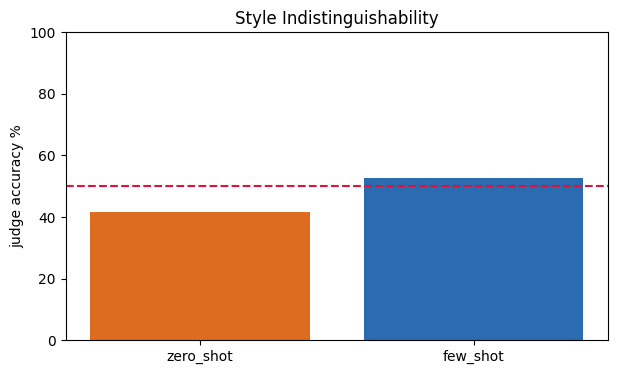

In [3]:
if rep:
    models = list(rep['results'])
    acc = [rep['results'][m]['indistinguishability']['accuracy']*100 for m in models]
    plt.figure(figsize=(7,4)); plt.bar(models, acc, color=['#dd6b20','#2b6cb0','#2f855a'][:len(models)])
    plt.axhline(50, ls='--', color='crimson'); plt.ylim(0,100); plt.ylabel('judge accuracy %')
    plt.title('Style Indistinguishability'); plt.show()

> The fine_tuned arm is added after the QLoRA GPU run (see README). Static figures are in `visuals/results/`.